# GNN training with k-fold cross-validation

Adapted from `train-GNN.ipynb`, replacing the single 80/10/10 train/validation/test split with grouped k-fold cross-validation. Materials (not individual graphs/polymorphs) are what get assigned to folds, mirroring the leakage-prevention logic already used in `split_dataset`.

What's different from the original:
- No fixed test set: every material is held out exactly once, across `n_splits` models
- Standardization is computed per fold, from that fold's training materials only (val statistics never leak into scaling)
- The final uncertainty estimate uses genuine out-of-fold residuals — the original reference set mixed in-sample and out-of-sample residuals from a single model, since train+val had already been seen during training
- An optional final section refits one deployable model on the full dataset, since none of the k fold-models individually sees 100% of the data

This trains `n_splits` separate models rather than one, so runtime scales accordingly. Periodic per-epoch parity plots were dropped in favor of one plot per fold, to keep the notebook readable.

# Load libraries and set device up

In [1]:
import numpy    as np
import torch.nn as nn
import os
import torch

import libraries.model   as clm
import libraries.dataset as cld

from torch_geometric.loader import DataLoader

# Checking if pytorch can run in GPU, else CPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

/home/claudio/cibran/Work/UCL/ml-phasetransitions/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
target_folder = 'model'

In [3]:
files_names = {
    'dataset':            f'{target_folder}/dataset.pt',
    'dataset_parameters': f'{target_folder}/dataset_parameters.json',
    'model_parameters':   f'{target_folder}/model_parameters.json',
    'cv_summary':         f'{target_folder}/cv_summary.json',
    'uncertainty_data':   f'{target_folder}/uncertainty_data.json'
}
cld.save_json(files_names, f'{target_folder}/files_names.json')


def get_fold_files_names(fold_idx):
    """Per-fold file paths, so each fold's standardized data/checkpoints don't overwrite one another.

    Args:
        fold_idx (int): Index of the current fold.

    Returns:
        dict: File paths for this fold's train/val datasets, standardization parameters, and model checkpoint.
    """
    return {
        'train_dataset_std': f'{target_folder}/fold{fold_idx}_train_dataset_std.pt',
        'val_dataset_std':   f'{target_folder}/fold{fold_idx}_val_dataset_std.pt',
        'std_parameters':    f'{target_folder}/fold{fold_idx}_standardized_parameters.json',
        'model':             f'{target_folder}/fold{fold_idx}_model.pt'
    }

# Define parameters

In [4]:
n_epochs =      400
batch_size =    128
learning_rate = 0.0001
dropout =       0.2
patience =      n_epochs
delta =         2
n_splits =      10   # number of folds for k-fold cross-validation

model_parameters = {
    'n_epochs':      n_epochs,
    'batch_size':    batch_size,
    'learning_rate': learning_rate,
    'dropout':       dropout,
    'patience':      patience,
    'delta':         delta,
    'n_splits':      n_splits
}
cld.save_json(model_parameters, files_names['model_parameters'])

# Generate or load graph database for training

In [5]:
# Try loading the previously generated raw dataset directly, else generate it
if not os.path.exists(files_names['dataset']):
    cld.generate_dataset('datasets/phonon-database',
                         targets=['free-energy'],
                         data_folder=target_folder)

dataset = torch.load(files_names['dataset'], weights_only=False)

# Material label is the first token of data.label (e.g. polymorphs share a material label)
material_labels_all = np.array([data.label.split()[0] for data in dataset])
print(f'Loaded {len(dataset)} graphs from {len(np.unique(material_labels_all))} unique materials')

Loaded 46571 graphs from 5403 unique materials


# Build k-fold splits

Groups graphs by material label and assigns whole materials to folds, so every polymorph of a given material stays together — the same rule `split_dataset` already used to keep train/val/test from leaking. A fixed seed makes the fold assignment reproducible across reruns.

In [6]:
def get_material_kfold_splits(material_labels, n_splits, seed=123):
    """Group graphs by material label and build k roughly-balanced folds.

    Keeps every polymorph of a given material in the same fold, mirroring the
    leakage-prevention logic already used in libraries.dataset.split_dataset.

    Args:
        material_labels (np.ndarray): Material label (first token of data.label) per graph.
        n_splits         (int):       Number of folds (k).
        seed              (int):      Random seed for reproducible fold assignment.

    Returns:
        list: List of (train_labels, val_labels) tuples, one per fold — arrays of unique
            material labels assigned to that fold's train/validation split.
    """
    unique_labels = np.unique(material_labels)

    rng = np.random.RandomState(seed)
    shuffled_labels = unique_labels.copy()
    rng.shuffle(shuffled_labels)

    fold_label_groups = np.array_split(shuffled_labels, n_splits)

    splits = []
    for fold_idx in range(n_splits):
        val_labels   = fold_label_groups[fold_idx]
        train_labels = np.concatenate([g for i, g in enumerate(fold_label_groups) if i != fold_idx])
        splits.append((train_labels, val_labels))
    return splits


fold_splits = get_material_kfold_splits(material_labels_all, n_splits)

for fold_idx, (train_labels, val_labels) in enumerate(fold_splits):
    print(f'Fold {fold_idx + 1}/{n_splits}: {len(train_labels)} train materials, {len(val_labels)} val materials')

Fold 1/12: 4952 train materials, 451 val materials
Fold 2/12: 4952 train materials, 451 val materials
Fold 3/12: 4952 train materials, 451 val materials
Fold 4/12: 4953 train materials, 450 val materials
Fold 5/12: 4953 train materials, 450 val materials
Fold 6/12: 4953 train materials, 450 val materials
Fold 7/12: 4953 train materials, 450 val materials
Fold 8/12: 4953 train materials, 450 val materials
Fold 9/12: 4953 train materials, 450 val materials
Fold 10/12: 4953 train materials, 450 val materials
Fold 11/12: 4953 train materials, 450 val materials
Fold 12/12: 4953 train materials, 450 val materials


# Train one model per fold

For each fold: standardize using only that fold's training materials, train a fresh model with early stopping, reload the best checkpoint, then evaluate on the held-out fold.

Note: each fold's held-out materials serve both as the early-stopping signal and the reported fold metric — the standard simplification for k-fold CV. A stricter nested CV would use a separate inner split for stopping, at the cost of roughly k× more training runs.


===== Fold 1/12 =====
Epoch: 20, Train MAE: 50.2059, Val MAE: 45.4087
Epoch: 40, Train MAE: 37.7289, Val MAE: 35.4142
Epoch: 60, Train MAE: 32.0747, Val MAE: 33.3385
Epoch: 80, Train MAE: 29.2985, Val MAE: 31.2683
Epoch: 100, Train MAE: 26.9341, Val MAE: 27.6123
Epoch: 120, Train MAE: 25.8048, Val MAE: 28.6804
Epoch: 140, Train MAE: 24.3152, Val MAE: 26.1665
Epoch: 160, Train MAE: 23.3528, Val MAE: 25.0174
Epoch: 180, Train MAE: 22.7919, Val MAE: 24.1813
Epoch: 200, Train MAE: 21.6630, Val MAE: 23.1224
Epoch: 220, Train MAE: 21.2947, Val MAE: 23.7879
Epoch: 240, Train MAE: 20.3190, Val MAE: 22.4351
Epoch: 260, Train MAE: 20.5306, Val MAE: 21.3342
Epoch: 280, Train MAE: 19.4741, Val MAE: 22.2554
Epoch: 300, Train MAE: 18.9958, Val MAE: 21.4406
Epoch: 320, Train MAE: 18.4441, Val MAE: 21.8202
Epoch: 340, Train MAE: 17.9314, Val MAE: 22.0567
Epoch: 360, Train MAE: 17.5158, Val MAE: 20.6585
Epoch: 380, Train MAE: 16.8705, Val MAE: 20.0976
Epoch: 400, Train MAE: 16.7020, Val MAE: 21.2657
F

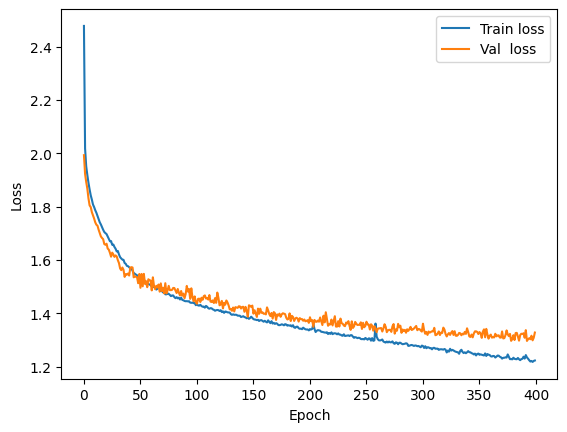

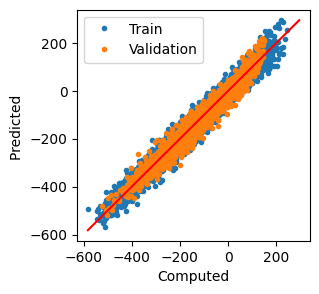


===== Fold 2/12 =====
Epoch: 20, Train MAE: 7121.7804, Val MAE: 45.6734
Epoch: 40, Train MAE: 4247.2327, Val MAE: 24.8831
Epoch: 60, Train MAE: 3550.5896, Val MAE: 22.7397
Epoch: 80, Train MAE: 7991.6291, Val MAE: 26.0168
Epoch: 100, Train MAE: 19886.8375, Val MAE: 21.3176
Epoch: 120, Train MAE: 825.5801, Val MAE: 19.7543
Epoch: 140, Train MAE: 1946.9961, Val MAE: 19.5393
Epoch: 160, Train MAE: 912.8146, Val MAE: 19.1662
Epoch: 180, Train MAE: 30.4879, Val MAE: 18.3039
Epoch: 200, Train MAE: 28.9283, Val MAE: 17.9777
Epoch: 220, Train MAE: 27.5017, Val MAE: 17.6799
Epoch: 240, Train MAE: 26.3996, Val MAE: 17.0787
Epoch: 260, Train MAE: 25.7110, Val MAE: 16.6186
Epoch: 280, Train MAE: 25.0609, Val MAE: 16.3035
Epoch: 300, Train MAE: 24.2043, Val MAE: 16.0026
Epoch: 320, Train MAE: 77.9381, Val MAE: 15.9381
Epoch: 340, Train MAE: 23.9903, Val MAE: 15.6262
Epoch: 360, Train MAE: 23.3980, Val MAE: 15.3823
Epoch: 380, Train MAE: 38.7691, Val MAE: 15.1723
Epoch: 400, Train MAE: 23.8306, Val

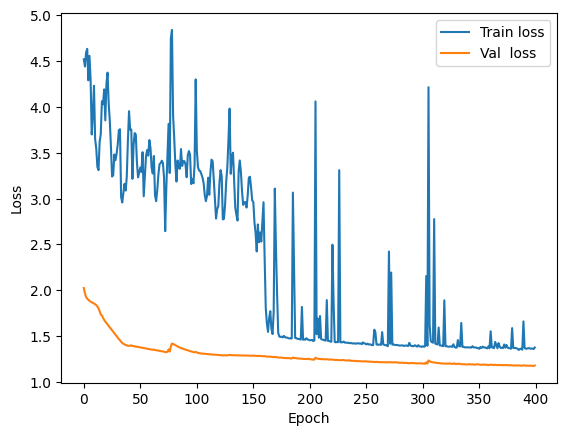

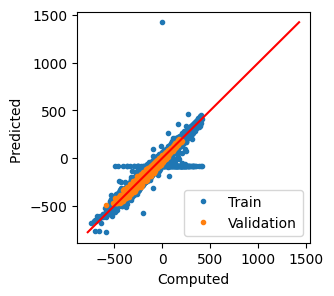


===== Fold 3/12 =====
Epoch: 20, Train MAE: 58754.3098, Val MAE: 63.0070
Epoch: 40, Train MAE: 153991.7636, Val MAE: 79.7408
Epoch: 60, Train MAE: 42199.4095, Val MAE: 66.2877
Epoch: 80, Train MAE: 3714.0065, Val MAE: 58.7377
Epoch: 100, Train MAE: 833.5200, Val MAE: 41.7799
Epoch: 120, Train MAE: 7342.4683, Val MAE: 56.4173
Epoch: 140, Train MAE: 283.6860, Val MAE: 37.6172
Epoch: 160, Train MAE: 83.0635, Val MAE: 34.5365
Epoch: 180, Train MAE: 70.6164, Val MAE: 31.0488
Epoch: 200, Train MAE: 58.5617, Val MAE: 26.5043
Epoch: 220, Train MAE: 51.5254, Val MAE: 25.9432
Epoch: 240, Train MAE: 48.5250, Val MAE: 25.4576
Epoch: 260, Train MAE: 49.2213, Val MAE: 25.0821
Epoch: 280, Train MAE: 46.6839, Val MAE: 25.0085
Epoch: 300, Train MAE: 47.2930, Val MAE: 25.0787
Epoch: 320, Train MAE: 45.6060, Val MAE: 25.2008
Epoch: 340, Train MAE: 45.4052, Val MAE: 24.9012
Epoch: 360, Train MAE: 45.0408, Val MAE: 25.2219
Epoch: 380, Train MAE: 43.9933, Val MAE: 25.5542
Epoch: 400, Train MAE: 43.8577, Va

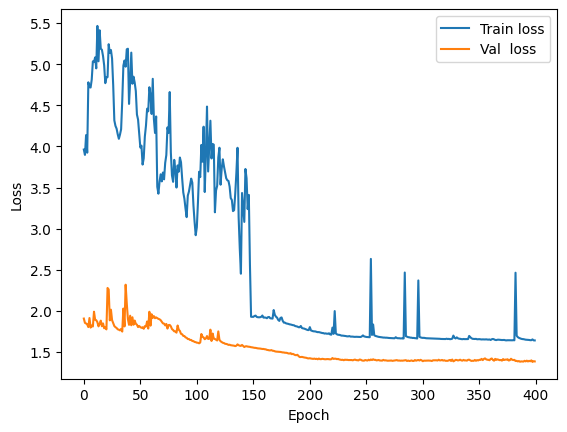

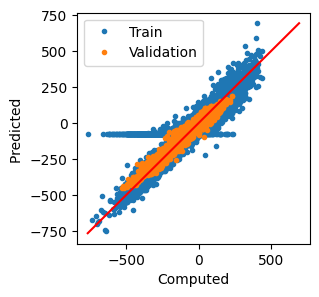


===== Fold 4/12 =====
Epoch: 20, Train MAE: 1395.6644, Val MAE: 42.8444
Epoch: 40, Train MAE: 154.2901, Val MAE: 36.6973
Epoch: 60, Train MAE: 1170.9228, Val MAE: 36.9917
Epoch: 80, Train MAE: 74.9078, Val MAE: 32.8179
Epoch: 100, Train MAE: 73.8975, Val MAE: 32.0811
Epoch: 120, Train MAE: 70.5033, Val MAE: 29.4129
Epoch: 140, Train MAE: 68.8199, Val MAE: 27.2578
Epoch: 160, Train MAE: 67.6500, Val MAE: 27.7416
Epoch: 180, Train MAE: 66.8729, Val MAE: 29.0214
Epoch: 200, Train MAE: 65.7323, Val MAE: 30.7084
Epoch: 220, Train MAE: 65.2206, Val MAE: 27.5557
Epoch: 240, Train MAE: 64.9841, Val MAE: 27.7747
Epoch: 260, Train MAE: 64.4115, Val MAE: 27.6207
Epoch: 280, Train MAE: 64.0309, Val MAE: 26.7913
Epoch: 300, Train MAE: 63.8499, Val MAE: 26.9553
Epoch: 320, Train MAE: 63.3979, Val MAE: 27.5103
Epoch: 340, Train MAE: 63.2087, Val MAE: 26.6150
Epoch: 360, Train MAE: 62.8899, Val MAE: 27.3758
Epoch: 380, Train MAE: 62.8762, Val MAE: 27.7304
Epoch: 400, Train MAE: 62.6817, Val MAE: 26.6

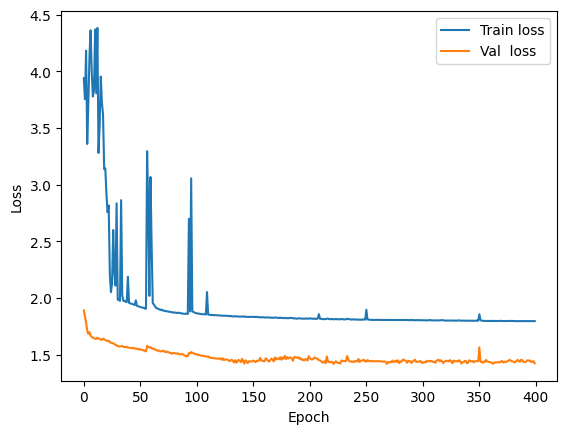

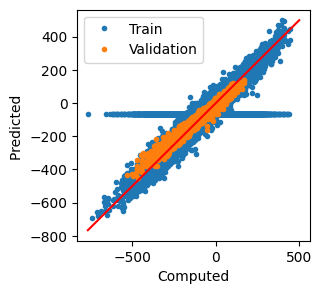


===== Fold 5/12 =====
Epoch: 20, Train MAE: 5433.2004, Val MAE: 52.1965
Epoch: 40, Train MAE: 1150.9557, Val MAE: 45.2258
Epoch: 60, Train MAE: 91.9017, Val MAE: 40.5432
Epoch: 80, Train MAE: 71.6474, Val MAE: 36.7156
Epoch: 100, Train MAE: 965.3300, Val MAE: 35.3370
Epoch: 120, Train MAE: 73.3546, Val MAE: 31.4805
Epoch: 140, Train MAE: 72.9872, Val MAE: 30.4935
Epoch: 160, Train MAE: 71.7077, Val MAE: 29.3791
Epoch: 180, Train MAE: 69.9294, Val MAE: 27.0228
Epoch: 200, Train MAE: 69.5485, Val MAE: 25.6114
Epoch: 220, Train MAE: 68.7136, Val MAE: 24.5175
Epoch: 240, Train MAE: 67.8182, Val MAE: 24.3276
Epoch: 260, Train MAE: 67.4517, Val MAE: 24.9086
Epoch: 280, Train MAE: 66.8196, Val MAE: 24.2984
Epoch: 300, Train MAE: 66.5980, Val MAE: 23.3723
Epoch: 320, Train MAE: 66.3938, Val MAE: 23.7573
Epoch: 340, Train MAE: 66.5389, Val MAE: 23.6241
Epoch: 360, Train MAE: 65.7313, Val MAE: 23.4151
Epoch: 380, Train MAE: 65.3696, Val MAE: 23.2514
Epoch: 400, Train MAE: 65.0335, Val MAE: 23.3

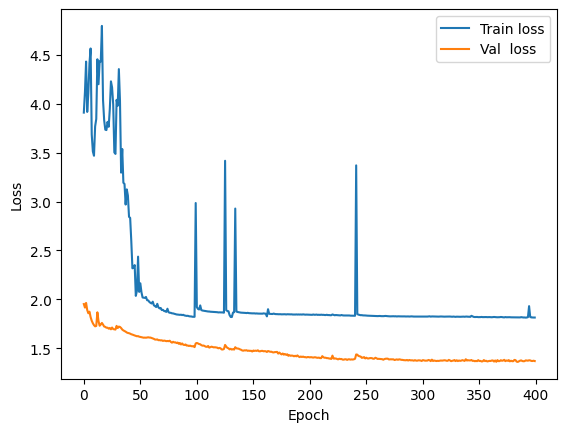

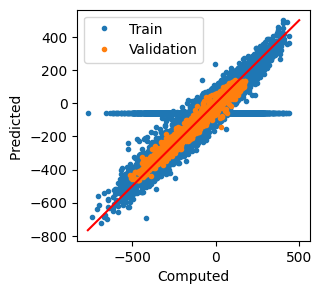


===== Fold 6/12 =====
Epoch: 20, Train MAE: 12551.6409, Val MAE: 82.1477
Epoch: 40, Train MAE: 18992.1560, Val MAE: 67.5018
Epoch: 60, Train MAE: 3099.4657, Val MAE: 63.8538
Epoch: 80, Train MAE: 3076.8479, Val MAE: 48.9872
Epoch: 100, Train MAE: 1810.7037, Val MAE: 42.2798
Epoch: 120, Train MAE: 734.0491, Val MAE: 42.9849
Epoch: 140, Train MAE: 85.1084, Val MAE: 39.1529
Epoch: 160, Train MAE: 131.8819, Val MAE: 38.9790
Epoch: 180, Train MAE: 79.5883, Val MAE: 36.0903
Epoch: 200, Train MAE: 80.6692, Val MAE: 35.9706
Epoch: 220, Train MAE: 77.5328, Val MAE: 33.8600
Epoch: 240, Train MAE: 75.3796, Val MAE: 32.1012
Epoch: 260, Train MAE: 74.1444, Val MAE: 29.6923
Epoch: 280, Train MAE: 72.4208, Val MAE: 27.8127
Epoch: 300, Train MAE: 85.3902, Val MAE: 26.7503
Epoch: 320, Train MAE: 71.1690, Val MAE: 26.8716
Epoch: 340, Train MAE: 69.6781, Val MAE: 25.7913
Epoch: 360, Train MAE: 67.2322, Val MAE: 24.7269
Epoch: 380, Train MAE: 68.9112, Val MAE: 24.6909
Epoch: 400, Train MAE: 68.3222, Val 

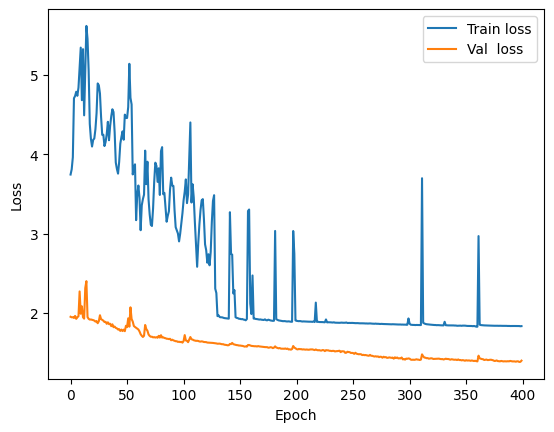

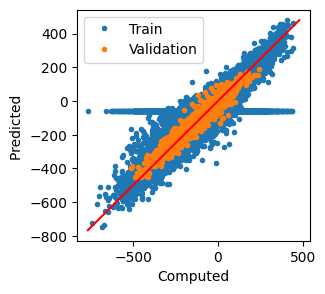


===== Fold 7/12 =====
Epoch: 20, Train MAE: 10138.8780, Val MAE: 172.3590
Epoch: 40, Train MAE: 10548.2973, Val MAE: 81.4844
Epoch: 60, Train MAE: 2905.9288, Val MAE: 58.5135
Epoch: 80, Train MAE: 115.9004, Val MAE: 50.0191
Epoch: 100, Train MAE: 85.2684, Val MAE: 42.4162
Epoch: 120, Train MAE: 81.0394, Val MAE: 41.2948
Epoch: 140, Train MAE: 75.2057, Val MAE: 40.3605
Epoch: 160, Train MAE: 70.2747, Val MAE: 36.8258
Epoch: 180, Train MAE: 71.7045, Val MAE: 38.1182
Epoch: 200, Train MAE: 66.6036, Val MAE: 36.4214
Epoch: 220, Train MAE: 65.0823, Val MAE: 34.7234
Epoch: 240, Train MAE: 62.8582, Val MAE: 34.5578
Epoch: 260, Train MAE: 60.6640, Val MAE: 33.5916
Epoch: 280, Train MAE: 58.1232, Val MAE: 32.7340
Epoch: 300, Train MAE: 56.5134, Val MAE: 31.7446
Epoch: 320, Train MAE: 55.1233, Val MAE: 32.4581
Epoch: 340, Train MAE: 53.5063, Val MAE: 30.9682
Epoch: 360, Train MAE: 51.9994, Val MAE: 30.7249
Epoch: 380, Train MAE: 51.2347, Val MAE: 30.3472
Epoch: 400, Train MAE: 51.7686, Val MAE:

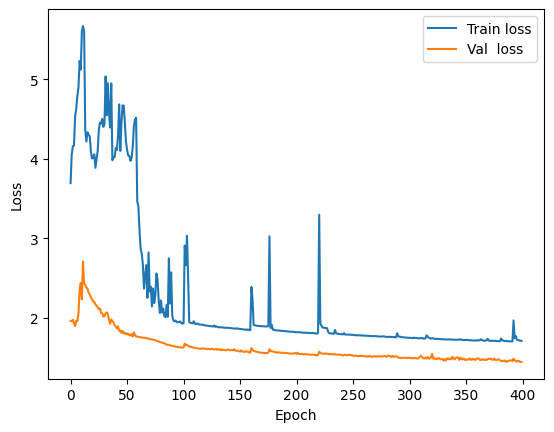

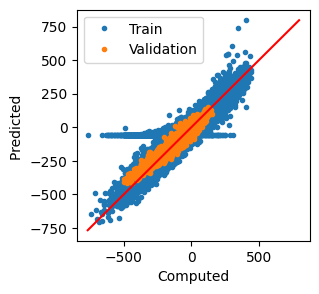


===== Fold 8/12 =====
Epoch: 20, Train MAE: 117.1176, Val MAE: 55.5759
Epoch: 40, Train MAE: 105.0342, Val MAE: 46.8805
Epoch: 60, Train MAE: 89.1988, Val MAE: 42.9523
Epoch: 80, Train MAE: 84.6323, Val MAE: 42.5207
Epoch: 100, Train MAE: 81.0772, Val MAE: 37.9460
Epoch: 120, Train MAE: 76.9514, Val MAE: 36.8657
Epoch: 140, Train MAE: 74.1997, Val MAE: 36.6403
Epoch: 160, Train MAE: 71.7139, Val MAE: 35.1958


KeyboardInterrupt: 

In [7]:
fold_results       = []
oof_labels         = []
oof_predictions    = []
oof_ground_truths  = []

criterion = torch.nn.MSELoss()  # MSELoss is by default defined as the mean within the batch

for fold_idx, (train_labels, val_labels) in enumerate(fold_splits):
    print(f'\n===== Fold {fold_idx + 1}/{n_splits} =====')

    fold_files_names = get_fold_files_names(fold_idx)

    # Split this fold's raw graphs by material label
    fold_train_dataset = cld.get_datasets(train_labels, material_labels_all, dataset)
    fold_val_dataset   = cld.get_datasets(val_labels,   material_labels_all, dataset)

    # Standardize using this fold's training data
    fold_train_dataset_std, fold_std_parameters = cld.standardize_dataset(fold_train_dataset,
                                                                          transformation='inverse-quadratic')
    fold_val_dataset_std = cld.standardize_dataset_from_keys(fold_val_dataset,
                                                             fold_std_parameters)

    cld.save_json(fold_std_parameters, fold_files_names['std_parameters'])

    fold_target_factor = np.array(fold_std_parameters['target_std']) / fold_std_parameters['scale']

    fold_train_loader = DataLoader(fold_train_dataset_std, batch_size=batch_size, shuffle=False, pin_memory=True)
    fold_val_loader   = DataLoader(fold_val_dataset_std,   batch_size=batch_size, shuffle=False, pin_memory=True)

    n_node_features = fold_train_dataset_std[0].num_node_features

    # Fresh model per fold
    model = clm.load_model(n_node_features, dropout, device, mode='train')

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

    fold_train_losses = []
    fold_val_losses   = []
    for epoch in range(n_epochs):
        train_loss, train_predictions, train_ground_truths = clm.train(model, criterion, fold_train_loader,
                                                                       fold_target_factor,
                                                                       fold_std_parameters['target_mean'],
                                                                       optimizer)
        val_loss,   val_predictions,   val_ground_truths   = clm.test(model, criterion, fold_val_loader,
                                                                       fold_target_factor,
                                                                       fold_std_parameters['target_mean'])

        # Convert to original units
        train_loss = np.sum(np.sqrt(train_loss) * fold_target_factor)
        val_loss   = np.sum(np.sqrt(val_loss)   * fold_target_factor)

        fold_train_losses.append(train_loss)
        fold_val_losses.append(val_loss)

        if (epoch + 1) % 20 == 0:
            print(f'Epoch: {epoch + 1}, Train MAE: {train_loss:.4f}, Val MAE: {val_loss:.4f}')

    val_loss, val_predictions, val_ground_truths = clm.test(model, criterion, fold_val_loader,
                                                             fold_target_factor,
                                                             fold_std_parameters['target_mean'])
    val_loss = np.sum(np.sqrt(val_loss) * fold_target_factor)

    print(f'Fold {fold_idx + 1}/{n_splits} best Val MAE: {val_loss:.4f}')

    cld.losses_plot(train_losses=fold_train_losses, val_losses=fold_val_losses, to_log=True)
    cld.parity_plot(train=np.array([train_ground_truths, train_predictions]),
                    validation=np.array([val_ground_truths, val_predictions]))

    # Record out-of-fold predictions - each material contributes exactly once,
    # from a model that never saw it during training
    for data in fold_val_dataset_std:
        oof_labels.append(f'{data.label} {data.y[0]}')
    oof_predictions.append(np.asarray(val_predictions))
    oof_ground_truths.append(np.asarray(val_ground_truths))

    fold_results.append({
        'fold':           fold_idx,
        'n_train_graphs': len(fold_train_dataset),
        'n_val_graphs':   len(fold_val_dataset),
        'val_mae':        float(val_loss),
        'train_losses':   [float(x) for x in fold_train_losses],
        'val_losses':     [float(x) for x in fold_val_losses]
    })

    # Free up memory before the next fold
    del model, optimizer, fold_train_loader, fold_val_loader
    if device.type == 'cuda':
        torch.cuda.empty_cache()

# Aggregate cross-validation results

In [ ]:
oof_predictions   = np.concatenate(oof_predictions)
oof_ground_truths = np.concatenate(oof_ground_truths)

fold_maes = np.array([r['val_mae'] for r in fold_results])
print(f'K-fold CV MAE: {fold_maes.mean():.4f} +/- {fold_maes.std():.4f}')
for r in fold_results:
    print(f"  Fold {r['fold'] + 1}: {r['val_mae']:.4f}  ({r['n_train_graphs']} train / {r['n_val_graphs']} val graphs)")

# Every material was validated exactly once, by a model that never trained on
# it - so this parity plot covers the full dataset without needing a separate
# held-out test split
cld.parity_plot(validation=np.array([oof_ground_truths, oof_predictions]),
                save_to=f'{target_folder}/GCNN-kfold-parity.pdf')

cv_summary = {
    'n_splits':     n_splits,
    'fold_val_mae': fold_maes.tolist(),
    'mean_val_mae': float(fold_maes.mean()),
    'std_val_mae':  float(fold_maes.std())
}
cld.save_json(cv_summary, files_names['cv_summary'])

# Compare fold loss curves

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))
for r in fold_results:
    plt.plot(r['val_losses'], label=f"Fold {r['fold'] + 1}")
plt.xlabel('Epoch')
plt.ylabel('Validation MAE')
plt.yscale('log')
plt.legend()
plt.title('Validation loss per fold')
plt.show()

# Generate uncertainties from out-of-fold predictions

Unlike the original train/val/test version — where the reference dataset's predictions came from a single model that had already trained on the train+val portion of it — every prediction here is out-of-fold: each material's residual comes from the one fold-model that never saw it during training. This gives a less biased basis for the interpolator.

In [ ]:
# label: uncertainty = ground-truth - prediction
uncertainties = oof_ground_truths - oof_predictions

# Standardize for better interpolation
uncert_mean  = uncertainties.mean()
uncert_std   = uncertainties.std()
uncert_scale = 1

uncertainties_std = (uncertainties - uncert_mean) * uncert_scale / uncert_std

# Check all labels are unique, otherwise you should rename them
if len(oof_labels) == len(set(oof_labels)):
    print('All labels are unique')
else:
    print('Error: some labels are duplicated')

# Generate dictionary with uncertainty data
uncertainty_values = {}
for idx in range(len(oof_labels)):
    uncertainty_values.update(
        {oof_labels[idx]: float(uncertainties_std[idx])}
    )
uncertainty_data = {
    'uncertainty_values': uncertainty_values,
    'uncert_mean':        uncert_mean,
    'uncert_std':         uncert_std,
    'uncert_scale':       uncert_scale
}

# Dump the dictionary with numpy arrays to a JSON file
cld.save_json(uncertainty_data, files_names['uncertainty_data'])